In [84]:
import numpy as np
import glob
import lgdo.lh5 as lh5
import os, json
import copy
import glob
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pygama.pargen.utils import load_data
from legendmeta import LegendMetadata
from dbetto import Props, TextDB, AttrsDict
import pandas as pd
from tqdm.notebook import tqdm
import awkward as ak
import polars as pl

from helper_lib import *
from resolution_extraction import weighted_resolution_from_nested_dict as wres_full
from resolution_extraction import weighted_resolution_per_detector as wres_det
from resolution_extraction import weighted_value_per_det_type as wval_dtype
from resolution_extraction import weighted_resolution_per_detector_type as wres_dtype
from resolution_extraction import get_eres_per_detector
import resolution_extraction as rex

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parquet file importing

In [3]:
df = pl.read_parquet("data.parquet")
print(df)

shape: (77_705_036, 11)
┌─────────────┬─────────────┬─────────┬─────────────────┬───┬────────────┬────────┬─────┬───────┐
│ energy      ┆ energy_sum  ┆ hit_idx ┆ is_good_channel ┆ … ┆ evtid      ┆ period ┆ run ┆ sim_e │
│ ---         ┆ ---         ┆ ---     ┆ ---             ┆   ┆ ---        ┆ ---    ┆ --- ┆ ---   │
│ f64         ┆ f64         ┆ i64     ┆ bool            ┆   ┆ f64        ┆ f64    ┆ f64 ┆ i64   │
╞═════════════╪═════════════╪═════════╪═════════════════╪═══╪════════════╪════════╪═════╪═══════╡
│ 199.774142  ┆ 199.774142  ┆ 0       ┆ true            ┆ … ┆ 0.0        ┆ 3.0    ┆ 0.0 ┆ 200   │
│ 200.157679  ┆ 200.157679  ┆ 0       ┆ true            ┆ … ┆ 3.0        ┆ 3.0    ┆ 0.0 ┆ 200   │
│ 200.132685  ┆ 200.132685  ┆ 0       ┆ true            ┆ … ┆ 4.0        ┆ 3.0    ┆ 0.0 ┆ 200   │
│ 199.554582  ┆ 199.554582  ┆ 0       ┆ true            ┆ … ┆ 5.0        ┆ 3.0    ┆ 0.0 ┆ 200   │
│ 199.286528  ┆ 199.286528  ┆ 0       ┆ true            ┆ … ┆ 6.0        ┆ 3.0    ┆ 0.0 ┆ 200 

# Working with resolutions

In [79]:
version = "v2.1.5"
base = f"/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/{version}/"
scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"
# metadata2_path = os.environ["METADATA"]
metadata2_path = "/global/homes/b/borrfran/workspace/l200/legend-metadata"
config = Props.read_from(base+"/config.json", subst_pathvar=True)['setups']['l200']['paths']


meta = LegendMetadata(config['metadata'])
meta2 = LegendMetadata(metadata2_path)

timestamp = meta.dataprod.runinfo.p03.r000.phy.start_key

chmap = meta.channelmap(timestamp)

DET_TYPES = ("BEGe", "COAX", "ICPC", "PPC")

could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fecd6ec4f90>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fecd6ec53a0>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fecd6ec53f0>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fecd6ec5940>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fecd6e439c0>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fecd6e43a10>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldat

## Populate Eres dictionaries

In [73]:
periods_simulated = ['p03', 'p04', 'p06', 'p07', 'p08', 'p09']
periods_metadata = meta2.datasets.runlists['valid']['phy']

periods_dict = {
    k: [item for rng in v for item in expand_range(rng)]
    for k, v in periods_metadata.items()
}

keys = list(periods_dict.keys())
for key in keys:
    if key not in periods_simulated:
        periods_dict.pop(key)

periods_dict['p09'].remove('r004')

In [81]:
eres_dict = get_eres_per_detector(meta2, config, periods_dict)
Props.write_to("./v1/dictionaries/eres_dict.yaml", eres_dict)

p09-r005: 100%|██████████| 101/101 [00:00<00:00, 3881.23it/s]


## Read Eres dict

In [10]:
eres_dict = Props.read_from("./v1/dictionaries/eres_dict.yaml")

### plot per-detector Eres at different energies

In [87]:
simulated_energies = range(200, 1100, 100)
res_per_det_tot = {}

for ene in tqdm(simulated_energies):
        
    res_per_det_tot[ene] = wres_det(eres_dict, ene)

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

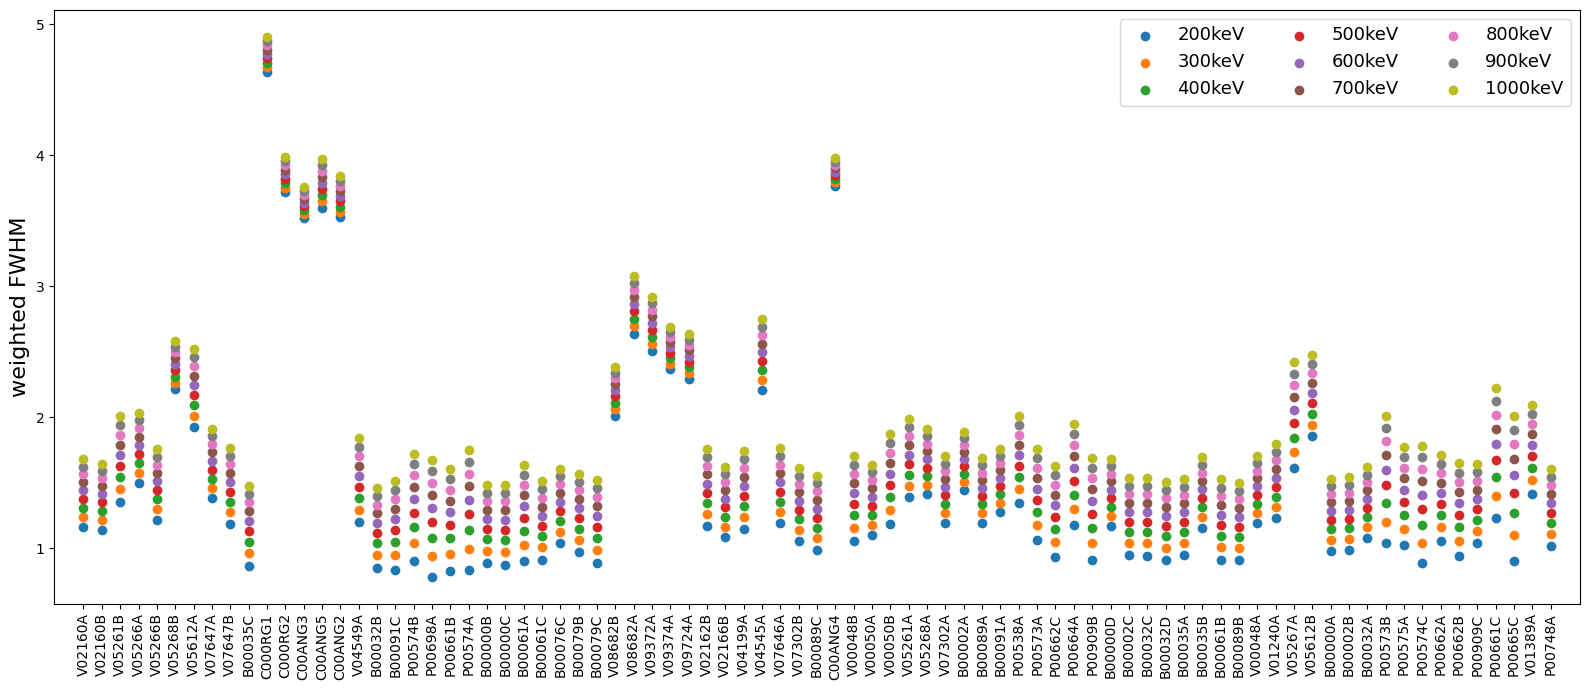

In [93]:
fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

for ene in tqdm(simulated_energies):
    
    keys = list(res_per_det_tot[ene].keys())
    values = [v['fwhm'] for v in res_per_det_tot[ene].values()]
    
    tag = f'{ene}keV'
    ax.scatter(keys, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

ax.set_ylabel(r"weighted FWHM", fontsize = 16)
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
plt.legend(ncol = 3, fontsize = 13)
# Padding sotto per non tagliare le etichette
plt.tight_layout()
plt.savefig("./plots/weighted_eres_per_energy.png", dpi=500)
plt.show()


### plot weighted averaged Eres at different energies

In [94]:
eres = {}

for ene in tqdm(simulated_energies):
    
     eres[ene] = wres_full(eres_dict, ene)

  0%|          | 0/9 [00:00<?, ?it/s]

In [98]:
eres.values()

dict_values([(1.6515972799818253, 0.019100773109158607), (1.7344742101709643, 0.018628015978885176), (1.81162983204287, 0.018229733941143834), (1.884291203102974, 0.017886078309148998), (1.9532675998601063, 0.01758490319493267), (2.0191353956774036, 0.0173180246796256), (2.082326126807027, 0.017079579152373917), (2.143174664580554, 0.016865179707127153), (2.2019480359756844, 0.016671436039734526)])

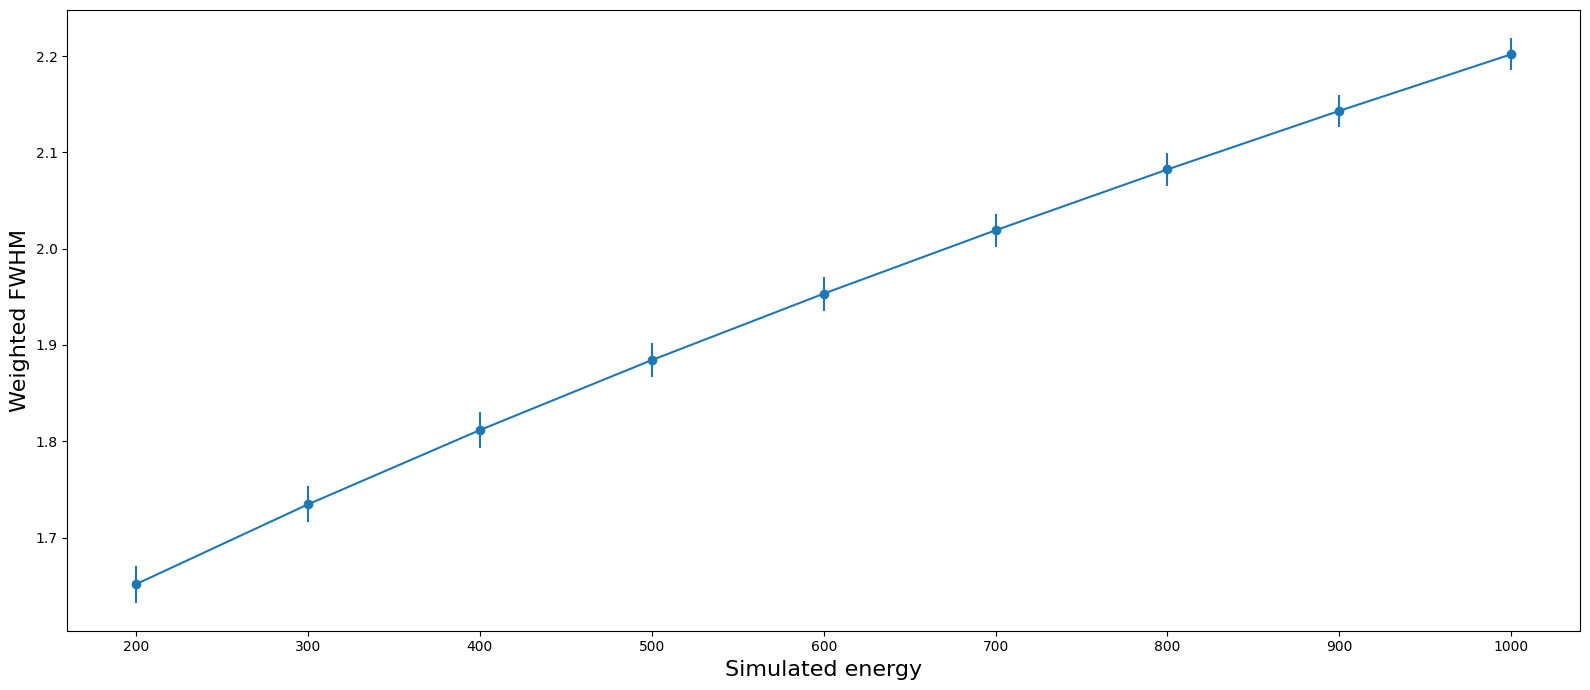

In [104]:
fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

keys, dict_val = eres.keys(), eres.values()

values = [v[0] for v in dict_val]
unc = [v[1] for v in dict_val]

ax.errorbar(keys, values, yerr = unc, marker = 'o')

ax.set_xlabel(r"Simulated energy", fontsize = 16)
ax.set_ylabel(r"Weighted FWHM", fontsize = 16)
# ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
# Padding sotto per non tagliare le etichette
plt.tight_layout()
plt.savefig("./plots/weighted_eres.png", dpi=500)
plt.show()


### plot per-det-type Eres at different energies

In [106]:
eres_dtype_full = {}
for ene in simulated_energies:
    for det_type, vals in wres_dtype(
        res_per_det_tot[ene]
    ).items():
        eres_dtype_full.setdefault(det_type, {})[ene] = vals


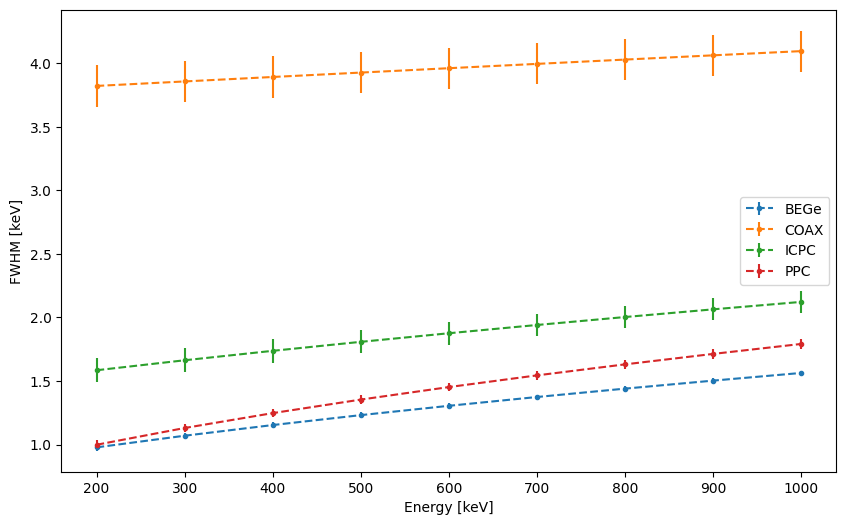

In [108]:
rex.plot_resolution_per_det_type(eres_dtype_full, simulated_energies, fig_name="./plots/fwhm_per_detector_type.png")

### Test difference weighted_fwhm vs weighted_parameters

In [109]:
w_values = wval_dtype(eres_dict, ["a", "b"]) # compute weighted mean of a and b to compute fwhm "a posteriori"

In [57]:
eres_dtype_full[det_type][ene]

{'fwhm': 1.5633940092676442, 'expo': 10.648178760742262}

In [113]:
eres_dtype_full[det_type]

{200: {'fwhm': 0.9985927204814006,
  'unc': 0.035783795755130424,
  'expo': 9.40290784749157},
 300: {'fwhm': 1.1304563391528692,
  'unc': 0.0335164484549354,
  'expo': 9.40290784749157},
 400: {'fwhm': 1.2474679503283121,
  'unc': 0.03298829359711224,
  'expo': 9.40290784749157},
 500: {'fwhm': 1.3539118345104004,
  'unc': 0.03343923606527315,
  'expo': 9.40290784749157},
 600: {'fwhm': 1.4522953756542964,
  'unc': 0.034458937803143526,
  'expo': 9.40290784749157},
 700: {'fwhm': 1.5442505394540786,
  'unc': 0.03580979537501147,
  'expo': 9.40290784749157},
 800: {'fwhm': 1.6309151949544374,
  'unc': 0.03735031510809461,
  'expo': 9.40290784749157},
 900: {'fwhm': 1.7131223893301395,
  'unc': 0.038994846383632445,
  'expo': 9.40290784749157},
 1000: {'fwhm': 1.7915047735573189,
  'unc': 0.0406908937178826,
  'expo': 9.40290784749157}}

In [114]:
det_type

'PPC'

In [118]:
output_pdf = "./plots/fwhm_method_comparison.pdf"

with PdfPages(output_pdf) as pdf:

    for det_type in DET_TYPES:
    
        fwhms_comp = [
            rex.compute_fwhm(a=w_values[det_type]['a'], 
                             b=w_values[det_type]['b'], 
                             energy=ene) 
            for ene in simulated_energies
        ]
        
        fwhms_wm = [
            eres_dtype_full[det_type][ene]['fwhm'] 
            for ene in simulated_energies
        ]

        fwhm_uncs = [
            eres_dtype_full[det_type][ene]['unc'] 
            for ene in simulated_energies
        ]
    
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.scatter(simulated_energies, fwhms_comp, color = 'tab:blue',
                    label=f"{det_type} - 'bad method'", ls = '--')
        ax.errorbar(simulated_energies, fwhms_wm, yerr = fwhm_uncs,
                    label=f"{det_type} - 'right method'", marker = '.',
                   color = 'tab:orange', ls = '--')
    
        ax.set_xlabel('Simulated energy [keV]')
        ax.set_ylabel('FWHM [keV]')
        ax.legend()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved PDF to {output_pdf}")

Saved PDF to ./plots/fwhm_method_comparison.pdf


In [115]:
fwhm_uncs

[0.035783795755130424,
 0.0335164484549354,
 0.03298829359711224,
 0.03343923606527315,
 0.034458937803143526,
 0.03580979537501147,
 0.03735031510809461,
 0.038994846383632445,
 0.0406908937178826]

In [72]:
period, run = 'p03', 'r000'
channel = 'ch1104000'

timestamp_cal = meta2.datasets.runinfo[period][run].cal.start_key
file_name = f"l200-{period}-{run}-cal-{timestamp_cal}-par_pht.json"

pars = Props.read_from(
    f"{config['par_pht']}/cal/{period}/{run}/{file_name}"
)

pars[channel]["results"]["partition_ecal"]["cuspEmax_ctc_cal"][
        "eres_linear"
    ]['cov'][0][1]

-7.297262654323861e-07

dict_keys(['ch1104000', 'ch1104001', 'ch1104002', 'ch1104003', 'ch1104004', 'ch1104005', 'ch1105600', 'ch1105602', 'ch1105603', 'ch1107202', 'ch1107203', 'ch1107204', 'ch1107205', 'ch1108800', 'ch1108801', 'ch1108802', 'ch1108803', 'ch1110402', 'ch1110403', 'ch1110404', 'ch1112000', 'ch1112001', 'ch1112002', 'ch1112003', 'ch1112004', 'ch1112005', 'ch1113600', 'ch1113601', 'ch1113602', 'ch1113603', 'ch1113604', 'ch1113605', 'ch1115203', 'ch1115204', 'ch1116801', 'ch1116802', 'ch1116803', 'ch1116804', 'ch1116805', 'ch1118402', 'ch1118403', 'ch1118404', 'ch1118405', 'ch1120000', 'ch1120001', 'ch1120002', 'ch1120003', 'ch1120004', 'ch1120005', 'ch1121600', 'ch1121601', 'ch1121602', 'ch1121603', 'ch1121604', 'ch1121605', 'ch1078400', 'ch1078405', 'ch1080000', 'ch1080001', 'ch1080004', 'ch1080005', 'ch1081600', 'ch1081601', 'ch1081602', 'ch1081603', 'ch1081604', 'ch1081605', 'ch1083201', 'ch1083202', 'ch1083203', 'ch1083204', 'ch1083205', 'ch1084800', 'ch1084801', 'ch1084802', 'ch1084803', '